In [2]:
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path

In [5]:
# get all jsonl files in this directory
log_dir = Path.cwd()
log_files = list(log_dir.glob("*.jsonl"))
for file in log_files:
    print(file.name)

opus_mt_es_en_embed_reg_baseline_lambda_0.0.jsonl
opus_mt_es_en_embed_reg_baseline_lambda_0.1.jsonl
opus_mt_es_en_embed_reg_baseline_lambda_1.0.jsonl
opus_mt_es_en_embed_reg_baseline_lambda_10.0.jsonl


dict_keys(['epoch', 'lambda_embed', 'gamma_uniform', 'use_word_aware_loss', 'use_uniform_loss', 'embedding_source', 'embed_loss_type', 'train_loss', 'train_ce_loss', 'train_embed_loss', 'train_uniform_loss', 'train_n_aux_vecs', 'val_loss', 'val_ce_loss', 'val_embed_loss', 'val_uniform_loss', 'val_n_aux_vecs', 'gen_bleu', 'gen_chrfpp', 'gen_n_eval_examples'])
dict_keys(['epoch', 'lambda_embed', 'gamma_uniform', 'use_word_aware_loss', 'use_uniform_loss', 'embedding_source', 'embed_loss_type', 'train_loss', 'train_ce_loss', 'train_embed_loss', 'train_uniform_loss', 'train_n_aux_vecs', 'val_loss', 'val_ce_loss', 'val_embed_loss', 'val_uniform_loss', 'val_n_aux_vecs', 'gen_bleu', 'gen_chrfpp', 'gen_n_eval_examples'])
dict_keys(['epoch', 'lambda_embed', 'gamma_uniform', 'use_word_aware_loss', 'use_uniform_loss', 'embedding_source', 'embed_loss_type', 'train_loss', 'train_ce_loss', 'train_embed_loss', 'train_uniform_loss', 'train_n_aux_vecs', 'val_loss', 'val_ce_loss', 'val_embed_loss', 'val_

C:\Users\KatherynZhou\AppData\Local\Temp\ipykernel_39712\4123593355.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("plasma")


Text(0.5, 1.0, 'Train Loss over Epochs for Different Lambda Embed Values')

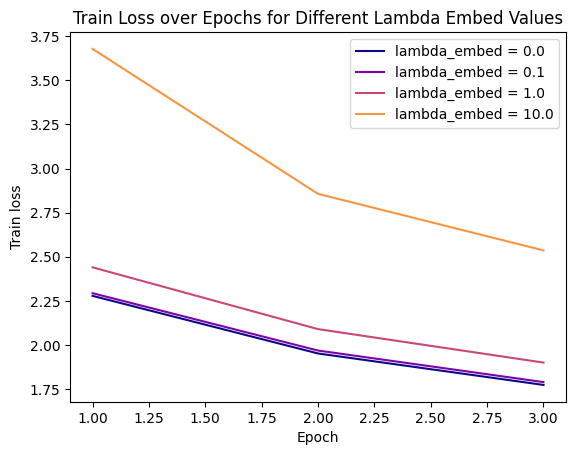

In [ ]:
for metric in ['train_loss', 'train_ce_loss', 'train_embed_loss', 'train_uniform_loss', 'train_n_aux_vecs', 'val_loss', 'val_ce_loss', 'val_embed_loss', 'val_uniform_loss', 'val_n_aux_vecs', 'gen_bleu', 'gen_chrfpp']:
    # set color map to magma, set each line to a different color evenly spaced across the color map:
    cmap = plt.cm.get_cmap("plasma")
    for file_i in range(len(log_files)):
        file = log_files[file_i]
        with file.open("r", encoding="utf-8") as f:
            records = [json.loads(line) for line in f]
        print(records[0].keys())
        lambda_val = records[0]["lambda_embed"]
        # plot train_loss and val_loss over epochs
        # only label the first one, to avoid duplicate labels in the legend
        plt.plot([r["epoch"] for r in records], [r[metric] for r in records], 
                label=f'lambda_embed = {lambda_val}',
                color=cmap(file_i / len(log_files))
                )
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"{metric} over Epochs for Different Lambda Embed Values")